# AI Final Project - Project 2
## Adversarial Attacks and Defenses on CIFAR-10

This notebook implements white-box adversarial attacks and defense mechanisms on a ResNet20 model trained/evaluated on CIFAR-10.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [2]:
# set the same seed for different random generators
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
BATCH_SIZE = 128
NUM_WORKERS = 2

In [6]:
# the folder of CIFAR-10
DATA_ROOT = "./data"
# validation size

VAL_SIZE = 5000

PIN_MEMORY = torch.cuda.is_available()

In [7]:
# chain of transforms: 
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), #pad 4 and randomly crop a 32*32 image
    transforms.RandomHorizontalFlip(), # generalizing for mirrored/original images
    transforms.ToTensor()
])

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

In [8]:
full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform
)

full_train_raw_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=raw_transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=raw_transform
)


CIFAR10_CLASSES = full_train_raw_dataset.classes

print("Classes:", CIFAR10_CLASSES)
print("Full train size:", len(full_train_raw_dataset))
print("Test size:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Full train size: 50000
Test size: 10000


In [9]:
num_train = len(full_train_raw_dataset)
indices = torch.randperm(num_train, generator=torch.Generator().manual_seed(RANDOM_SEED))

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

In [10]:
train_dataset = torch.utils.data.Subset(full_train_aug_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_raw_dataset, val_indices)
mean_std_dataset = torch.utils.data.Subset(full_train_raw_dataset, train_indices)

In [11]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # shuffle to reduce order bias
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [12]:
mean_std_loader = torch.utils.data.DataLoader(
    mean_std_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
) # this loader in only for computing statistics

In [13]:
# Sanity Check
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("First labels:", labels[:10])

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Min pixel value: 0.0
Max pixel value: 1.0
First labels: tensor([7, 4, 0, 1, 8, 1, 7, 6, 5, 5])


In [14]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1) # mean for each channel
        std = torch.tensor(std).view(1, 3, 1, 1) # std for each channel
        self.register_buffer("mean", mean) # save as untrainable parameter
        self.register_buffer("std", std) # save as untrainable parameter
        
    def forward(self, x):
        return (x - self.mean) / self.std

In [15]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0
    
    for images, _ in loader:
        batch_size, channels, height, width = images.shape
        
        num_pixels += batch_size * height * width # pixels per channel
        
        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])
        
    mean = channels_sum / num_pixels 
    # std = sqrt(E(x^2)-E(x)^2)
    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)
    
    return mean, std

In [16]:
cifar10_mean, cifar10_std = compute_mean_std(mean_std_loader)

cifar10_mean = cifar10_mean.tolist()
cifar10_std = cifar10_std.tolist()

print("Mean:", cifar10_mean)
print("Std:", cifar10_std)

Mean: [0.4913501441478729, 0.4821614623069763, 0.44659730792045593]
Std: [0.24704869091510773, 0.24355383217334747, 0.26168447732925415]


In [17]:
class BasicBlock(nn.Module):
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        # The 'Shortcut' connection (Identity mapping)
        self.shortcut = nn.Sequential()
        # if input size doesn't match the output
        # we apply a 1*1 convolution to the shortcut
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = out + self.shortcut(x)
        out = F.relu(out)
        
        return out

In [18]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.in_channels = 16
        # proccess on the raw 3-channel (RGB) image
        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)
        # feature map size 32*32, 16 channels
        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )
        # 16*16 -> 32 (Downsample with stride 2)
        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )
        # 8*8 to 64 (Downsample with tride 2)
        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
        
        self._initialize_weights()
        
    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        # handel the first layer seperately 
        # because of stride, and change of shape
        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )
        
        self.in_channels = out_channels
        
        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )
            
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)
                
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        
        return out

In [19]:
def build_resnet20_model(cifar10_mean, cifar10_std, device, num_classes=10):
    resnet20 = ResNet20(num_classes=num_classes)
    
    model = nn.Sequential(
        Normalize(cifar10_mean, cifar10_std),
        resnet20
    ).to(device)
    
    return model

In [20]:
model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [21]:
# Sanity Check
x_dummy = torch.rand(4, 3, 32, 32).to(device)

with torch.no_grad():
    logits = model(x_dummy)

print("Output shape:", logits.shape) # Should be [4, 10]

Output shape: torch.Size([4, 10])


In [22]:
EPOCHS = 30
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

SAVE_PATH = "resnet20_cifar10_clean.pth"

In [23]:
saved_model_exists = False

In [24]:
if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    
    saved_model_exists = True
    
    print(f"Loaded saved model from: {SAVE_PATH}")    
else:
    print("No saved model found. Training from scratch.")

Loaded saved model from: resnet20_cifar10_clean.pth


In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        logits = model(images)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad() # clear old gradients
        loss.backward() # compute new gradients
        optimizer.step() # update weights
        
        total_loss += loss.item() * labels.size(0) # or maybe images,size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [26]:
@torch.no_grad() # we don't need backpropagation during evaluation
def evaluate(model, loader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        # move images and labels to CPU/GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # comupte raw class scores , then classification loss
        logits = model(images)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        # predicted class is the largest logit
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [27]:
if not saved_model_exists:
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[15, 25],
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
            f"lr={scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )

    print("Best validation accuracy:", best_val_acc)
    print("Saved model:", SAVE_PATH)
else:
    print("Skipping training because saved model already exists.")

Skipping training because saved model already exists.


In [28]:
if not saved_model_exists:
    #TODO: make sure this part is not logically problematic ( it seems we are skipping loading the saved model)
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    print("Loaded best validation model.")

In [29]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet20 Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [30]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet20 Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
criterion = nn.CrossEntropyLoss()

val_loss, val_acc = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)

test_loss, test_acc = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Validation accuracy: 0.9024
Test accuracy: 0.8927


In [32]:
FGSM_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [33]:
def fgsm_attack(model, images, labels, epsilon, criterion, device):
    model.eval() # evaluation mode because we are attacking, not training

    # clone to avoid modifying the original images
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    images.requires_grad = True
    
    logits = model(images)
    loss = criterion(logits, labels) # compute loss
    
    model.zero_grad() # clear old gradients
    loss.backward() # backpropagation
    
    grad_sign = images.grad.sign()
    # move pixels in the direction that increases loss
    adv_images = images + epsilon * grad_sign
    adv_images = torch.clamp(adv_images, 0.0, 1.0)
    
    return adv_images.detach()

In [34]:
# Sanity Check 
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

tolerance = 1e-6

for sanity_check_eps in FGSM_EPSILONS:

    sanity_check_adv_images = fgsm_attack(
        model,
        sanity_check_images,
        sanity_check_labels,
        sanity_check_eps,
        criterion,
        device
    )

    delta = sanity_check_adv_images - sanity_check_images
    # x_adv - x <= epsilon
    assert delta.abs().max().item() <= sanity_check_eps + tolerance

In [35]:
def evaluate_fgsm(model, loader, epsilons, criterion, device):
    results = {}
    
    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0
        
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if epsilon == 0.0:
                adv_images = images 
            else:
                adv_images = fgsm_attack(
                    model,
                    images,
                    labels, 
                    epsilon,
                    criterion,
                    device
                )
                
            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)
                
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
        accuracy = total_correct / total_samples
        results[epsilon] = accuracy
        
        print(f"epsilon={epsilon:.5f} | accuracy={accuracy:.4f}")
        
    return results

In [36]:
criterion = nn.CrossEntropyLoss()

fgsm_results = evaluate_fgsm(
    model,
    test_loader,
    FGSM_EPSILONS,
    criterion,
    device
)

epsilon=0.00000 | accuracy=0.8927
epsilon=0.00784 | accuracy=0.2148
epsilon=0.01569 | accuracy=0.1211
epsilon=0.03137 | accuracy=0.0856
epsilon=0.06275 | accuracy=0.0780


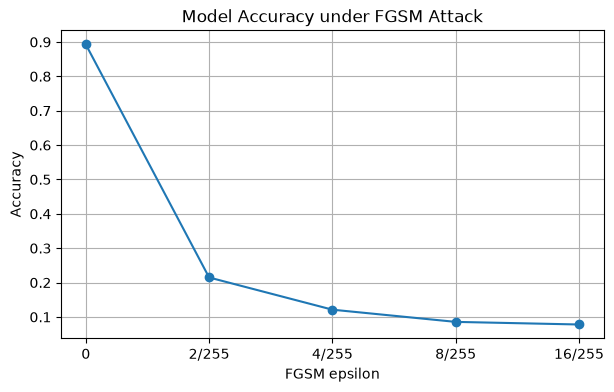

In [37]:
eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
accuracies = [fgsm_results[eps] for eps in FGSM_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(eps_labels, accuracies, marker="o")
plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under FGSM Attack")
plt.grid(True)
plt.show()

In [38]:
def get_confidence_and_pred(model, image):
    model.eval()
    
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        # convert logits to probabilities
        probs = F.softmax(logits, dim=1)
        # get highest probability and its class index
        
        confidence, pred = probs.max(dim=1)
        
    return confidence.item(), pred.item()

In [39]:
def find_correct_sample(model, loader, device, idx=0):
    model.eval()
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            logits = model(images)
            preds = logits.argmax(dim=1)
            
        correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
        
        if len(correct_indices) > 0:
            if idx >= len(correct_indices):
                idx = 0  
                
            sample_idx = correct_indices[idx].item()
            return images[sample_idx].detach().cpu(), labels[sample_idx].detach().cpu()
        
    raise RuntimeError("No correctly classified sample found.")

In [40]:
def show_fgsm_examples(model, loader, epsilons, criterion, class_names, device, idx=0):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    images_to_show = []
    titles = []

    true_label = label.item()

    for epsilon in epsilons:
        if epsilon == 0.0:
            display_image = clean_image.clone()
        else:
            adv_image = fgsm_attack(
                model=model,
                images=clean_image.unsqueeze(0),
                labels=label.unsqueeze(0),
                epsilon=epsilon,
                criterion=criterion,
                device=device
            )
            display_image = adv_image.squeeze(0).detach().cpu()

        confidence, pred = get_confidence_and_pred(model, display_image)

        images_to_show.append(display_image)

        if epsilon == 0.0:
            eps_text = "Clean"
        else:
            eps_text = f"eps={epsilon:.4f}"

        title = (
            f"{eps_text}\n"
            f"Pred: {class_names[pred]}\n"
            f"Conf: {confidence:.2f}"
        )

        titles.append(title)

    plt.figure(figsize=(15, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, len(images_to_show), i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(f"True Label: {class_names[true_label]}", fontsize=14)
    plt.tight_layout()
    plt.show()

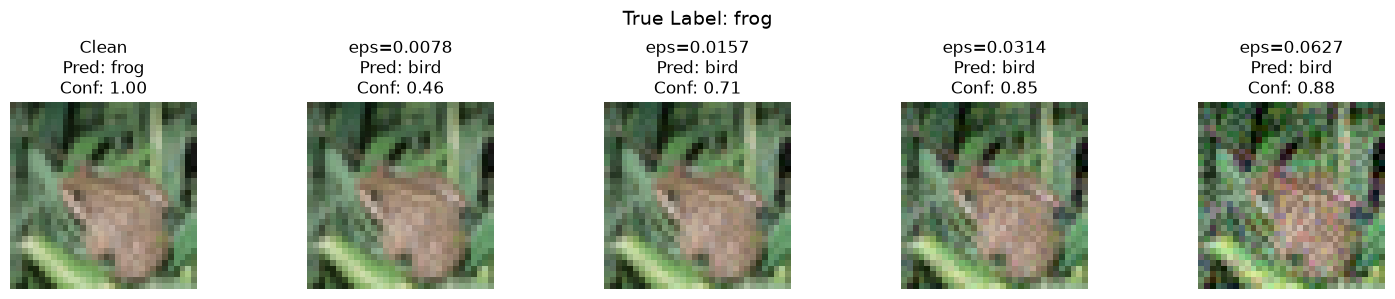

In [41]:
show_fgsm_examples(
    model=model,
    loader=test_loader,
    epsilons=FGSM_EPSILONS,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=4
)

In [42]:
def show_fgsm_example(
    model,
    loader,
    epsilon,
    criterion,
    class_names,
    device,
    idx=0
):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image = fgsm_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=epsilon,
        criterion=criterion,
        device=device
    ).squeeze(0).detach().cpu()

    noise = adv_image - clean_image

    noise_for_display = noise / (2 * epsilon) + 0.5
    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    l_inf = noise.abs().max().item()
    l2_norm = torch.norm(noise.flatten(), p=2).item()

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        "FGSM Noise\nscaled for display",
        f"FGSM Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Epsilon: {epsilon:.5f} | "
        f"L∞: {l_inf:.5f} | "
        f"L2: {l2_norm:.4f}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

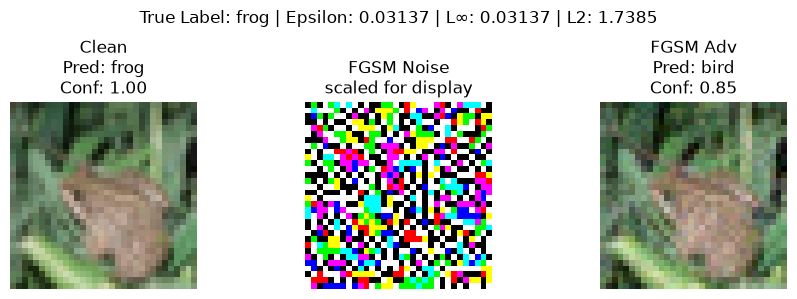

In [43]:
show_fgsm_example(
    model,
    test_loader,
    epsilon=8 / 255,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=4
)

In [44]:
PGD_EPSILON = 8 / 255
PGD_ALPHA = 2 / 255
PGD_STEPS = 20
PGD_RANDOM_START = True

In [45]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval() # use evaluation mode because it's an attack
    
    images = images.clone().detach().to(device) # clone to avoid modifying originals
    labels = labels.clone().detach().to(device)
    
    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon) # random start in an epsilon ball
        adv_images = images + delta # add random noise to original images
        adv_images = torch.clamp(adv_images, 0.0, 1.0) # make sure pixels are valid
    else:
        adv_images = images.clone().detach() # start from clean image
        
    for _ in range(num_steps):
        adv_images.requires_grad = True
        
        logits = model(adv_images) # forward pass
        loss = criterion(logits, labels) #compute loss
        
        model.zero_grad()
        loss.backward() #compute gradients
        
        with torch.no_grad():
            grad_sign = adv_images.grad.sign()
            # take one FGSM-like step
            adv_images = adv_images + alpha * grad_sign
            
            delta = adv_images - images
            delta = torch.clamp(delta, -epsilon, epsilon)
            
            adv_images = images + delta
            adv_images = torch.clamp(adv_images, 0.0, 1.0)
            
        adv_images = adv_images.detach()
        
    return adv_images

In [46]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

sanity_check_adv_images = pgd_attack(
    model,
    sanity_check_images,
    sanity_check_labels,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    random_start=PGD_RANDOM_START
)

delta = sanity_check_adv_images - sanity_check_images
max_delta = delta.abs().max().item()

print("Max |delta|:", max_delta)
print("Epsilon:", PGD_EPSILON)
print("Difference:", max_delta - PGD_EPSILON)
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert max_delta <= PGD_EPSILON + 1e-6
assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Max |delta|: 0.03137257695198059
Epsilon: 0.03137254901960784
Difference: 2.793237274811844e-08
Adv min: 0.0
Adv max: 1.0


In [47]:
def evaluate_pgd(model, loader, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval()
    
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        adv_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_steps,
            criterion,
            device,
            random_start
        )
        
        with torch.no_grad():
            logits = model(adv_images)
            preds = logits.argmax(dim=1)
            
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    accuracy = total_correct / total_samples
    
    print(
        f"PGD accuracy | "
        f"epsilon={epsilon:.5f}, "
        f"alpha={alpha:.5f}, "
        f"steps={num_steps}: "
        f"{accuracy:.4f}"
    )
    
    return accuracy

In [48]:
pgd_acc = evaluate_pgd(
    model,
    test_loader,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=20: 0.0000


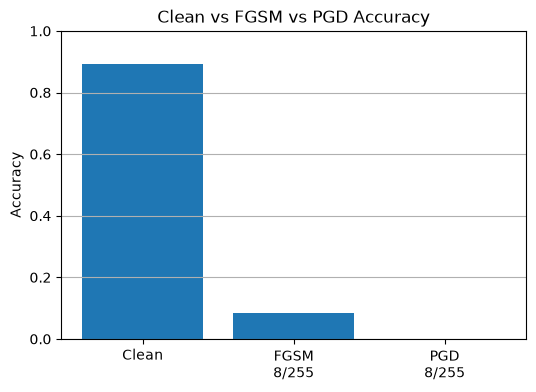

In [49]:
clean_acc = fgsm_results[0.0]
fgsm_acc_8_255 = fgsm_results[8 / 255]

attack_names = ["Clean", "FGSM\n8/255", "PGD\n8/255"]
attack_accuracies = [clean_acc, fgsm_acc_8_255, pgd_acc]

plt.figure(figsize=(6, 4))
plt.bar(attack_names, attack_accuracies)
plt.ylabel("Accuracy")
plt.title("Clean vs FGSM vs PGD Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [50]:
def show_pgd_example(
    model,
    loader,
    epsilon,
    alpha,
    num_steps,
    criterion,
    class_names,
    device,
    random_start=True,
    idx=0
):
    # Get a correctly classified sample
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image = pgd_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=epsilon,
        alpha=alpha,
        num_steps=num_steps,
        criterion=criterion,
        device=device,
        random_start=random_start
    ).squeeze(0).detach().cpu()

    noise = adv_image - clean_image
    # Scale noise to [0, 1] for display
    noise_for_display = noise / (2 * epsilon) + 0.5
    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        "PGD Noise\nscaled for display",
        f"PGD Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(f"True Label: {class_names[label.item()]}", fontsize=14)
    plt.tight_layout()
    plt.show()

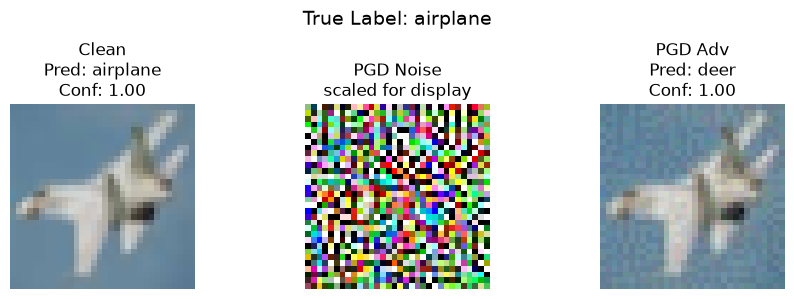

In [51]:
show_pgd_example(
    model,
    test_loader,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    CIFAR10_CLASSES,
    device,
    PGD_RANDOM_START,
    idx=10
)

In [52]:
PGD_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [53]:
def evaluate_pgd_multiple_eps(
    model,
    loader,
    epsilons,
    num_steps,
    criterion,
    device,
    random_start=True
):
    model.eval()
    
    results = {}
    
    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0
        
        if epsilon == 0.0:
            alpha = 0
        else:
            alpha = epsilon / 4
            
        for images,labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if epsilon == 0.0:
                adv_images = images
            else:
                adv_images = pgd_attack(
                    model,
                    images,
                    labels,
                    epsilon,
                    alpha,
                    num_steps,
                    criterion,
                    device,
                    random_start=random_start
                )
                
            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)
            
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
        accuracy = total_correct / total_samples
        
        results[epsilon] = accuracy
        
    
        print(
            f"epsilon={epsilon:.5f} | "
            f"alpha={alpha:.5f} | "
            f"steps={num_steps} | "
            f"accuracy={accuracy:.4f}"
        )
        
    return results

In [54]:
pgd_results = evaluate_pgd_multiple_eps(
    model,
    test_loader,
    PGD_EPSILONS,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

epsilon=0.00000 | alpha=0.00000 | steps=20 | accuracy=0.8927
epsilon=0.00784 | alpha=0.00196 | steps=20 | accuracy=0.0058
epsilon=0.01569 | alpha=0.00392 | steps=20 | accuracy=0.0000
epsilon=0.03137 | alpha=0.00784 | steps=20 | accuracy=0.0000
epsilon=0.06275 | alpha=0.01569 | steps=20 | accuracy=0.0000


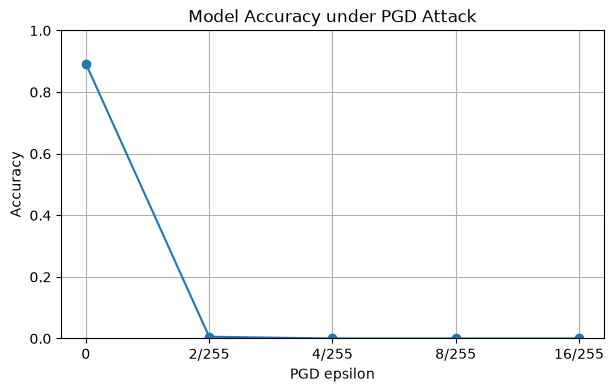

In [55]:
pgd_eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o")
plt.xlabel("PGD epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under PGD Attack")
plt.grid(True)
plt.ylim(0, 1)
plt.show()

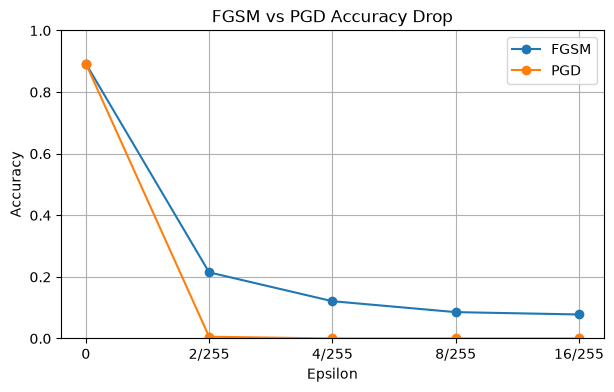

In [56]:
fgsm_accuracies = [fgsm_results[eps] for eps in PGD_EPSILONS]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, fgsm_accuracies, marker="o", label="FGSM")
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o", label="PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM vs PGD Accuracy Drop")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [57]:
DEEPFOOL_MAX_ITER = 50
DEEPFOOL_NUM_CLASSES = 10
DEEPFOOL_OVERSHOOT = 0.02
DEEPFOOL_EVAL_SIZE = 500

In [58]:
def deepfool_attack_single_image(
    model,
    image,
    device,
    num_classes=10,
    max_iter=50,
    overshoot=0.02
):
    model.eval()

    image = image.clone().detach().to(device)
    # initial prediction
    with torch.no_grad():
        logits = model(image.unsqueeze(0))
        initial_pred = logits.argmax(dim=1).item()

    adv_image = image.clone().detach()
    perturbation = torch.zeros_like(image).to(device)

    final_pred = initial_pred
    num_iter = 0
    # Loop until misclassified or max iterations reached
    while final_pred == initial_pred and num_iter < max_iter:
        adv_image.requires_grad = True

        logits = model(adv_image.unsqueeze(0)).squeeze(0)
        # Consider only top-k most probable classes
        sorted_classes = torch.argsort(logits, descending=True)
        sorted_classes = sorted_classes[:num_classes]

        current_class = initial_pred

        model.zero_grad()
        # Gradient for true class
        current_logit = logits[current_class]
        current_grad = torch.autograd.grad(
            current_logit,
            adv_image,
            retain_graph=True,
            create_graph=False
        )[0]

        min_distance = float("inf")
        best_perturbation = None

        for class_idx in sorted_classes:
            class_idx = class_idx.item()

            if class_idx == current_class:
                continue

            class_logit = logits[class_idx]

            class_grad = torch.autograd.grad(
                class_logit,
                adv_image,
                retain_graph=True,
                create_graph=False
            )[0]

            w_k = class_grad - current_grad
            f_k = class_logit - current_logit

            w_k_norm = torch.norm(w_k.flatten(), p=2)
            # Distance to decision boundary
            if w_k_norm.item() == 0:
                continue
            # Choose smallest required distance
            distance = torch.abs(f_k) / w_k_norm

            if distance.item() < min_distance:
                min_distance = distance.item()
                best_perturbation = (torch.abs(f_k) / (w_k_norm ** 2)) * w_k

        if best_perturbation is None:
            break

        perturbation = perturbation + best_perturbation.detach()
        # Apply overshoot to cross boundary (to make sure it goes to the wrong class)
        adv_image = image + (1 + overshoot) * perturbation
        adv_image = torch.clamp(adv_image, 0.0, 1.0).detach()

        with torch.no_grad():
            final_logits = model(adv_image.unsqueeze(0))
            final_pred = final_logits.argmax(dim=1).item()

        num_iter += 1

    success = final_pred != initial_pred
    final_perturbation = adv_image - image

    return adv_image.detach(), final_perturbation.detach(), initial_pred, final_pred, num_iter, success

In [59]:
# Sanity Check

sample_images, sample_labels = next(iter(test_loader))

sample_image = sample_images[0].to(device)
sample_label = sample_labels[0].item()

adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
    model,
    sample_image,
    device,
    DEEPFOOL_NUM_CLASSES,
    DEEPFOOL_MAX_ITER,
    DEEPFOOL_OVERSHOOT
)

print("True label:", CIFAR10_CLASSES[sample_label])
print("Initial prediction:", CIFAR10_CLASSES[initial_pred])
print("Final prediction:", CIFAR10_CLASSES[final_pred])
print("Iterations:", num_iter)
print("Success:", success)
print("L2 perturbation:", torch.norm(perturbation.flatten(), p=2).item())
print("Adv min:", adv_image.min().item())
print("Adv max:", adv_image.max().item())

assert adv_image.min().item() >= 0.0
assert adv_image.max().item() <= 1.0

True label: cat
Initial prediction: cat
Final prediction: dog
Iterations: 1
Success: True
L2 perturbation: 0.08408286422491074
Adv min: 0.051014333963394165
Adv max: 0.9999100565910339


In [60]:
def evaluate_deepfool(
    model,
    loader,
    max_samples,
    num_classes,
    max_iter,
    overshoot,
    device
):
    model.eval()
    
    total_samples = 0
    clean_correct = 0
    adv_correct = 0
    
    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []
    
    for images, labels in loader:
        for i in range(images.size(0)):
            if total_samples >= max_samples:
                break
                
            image = images[i].to(device)
            label = labels[i].to(device)
            # evaluate clean image
            with torch.no_grad():
                clean_logits = model(image.unsqueeze(0))
                clean_pred = clean_logits.argmax(dim=1).item()
                
            total_samples += 1
            # if the model predicts correctly, attack
            if clean_pred == label.item():
                clean_correct += 1
                # generate adversarial example with deepfool
                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    model,
                    image,
                    device,
                    num_classes,
                    max_iter,
                    overshoot
                )
                
                attacked_samples += 1
                
                with torch.no_grad():
                    adv_logits = model(adv_image.unsqueeze(0))
                    adv_pred = adv_logits.argmax(dim=1).item()
                    
                if adv_pred == label.item():
                    adv_correct += 1
                else: 
                    successful_attacks += 1
                    # record the L2 norm
                    l2_norm = torch.norm(perturbation.flatten(), p=2).item()
                    l2_norm_successful.append(l2_norm)
                    
            if total_samples % 50 == 0:
                print(f"Processed {total_samples}/{max_samples} samples")
                
        if total_samples >= max_samples:
            break
            
    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples
    
    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0
        
    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else: 
        avg_l2_successful = 0.0
        
    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nDeepFool Results")
    print("----------------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after DeepFool: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results             

In [61]:
deepfool_results = evaluate_deepfool(
    model,
    test_loader,
    max_samples=DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9080
Robust accuracy after DeepFool: 0.0000
Attacked initially correct samples: 454
Successful attacks: 454
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.108918


In [62]:
def show_deepfool_example(
    model,
    loader,
    num_classes,
    max_iter,
    overshoot,
    class_names,
    device,
    idx=0
):
    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
        model=model,
        image=clean_image,
        device=device,
        num_classes=num_classes,
        max_iter=max_iter,
        overshoot=overshoot
    )

    clean_image = clean_image.detach().cpu()
    adv_image = adv_image.detach().cpu()
    perturbation = perturbation.detach().cpu()

    l2_norm = torch.norm(perturbation.flatten(), p=2).item()

    max_abs_noise = perturbation.abs().max().item()

    if max_abs_noise > 0:
        noise_for_display = perturbation / (2 * max_abs_noise) + 0.5
    else:
        noise_for_display = perturbation + 0.5

    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[initial_pred]}",
        f"DeepFool Noise\nL2: {l2_norm:.4f}",
        f"Adversarial\nPred: {class_names[final_pred]}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Iterations: {num_iter} | "
        f"Success: {success}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

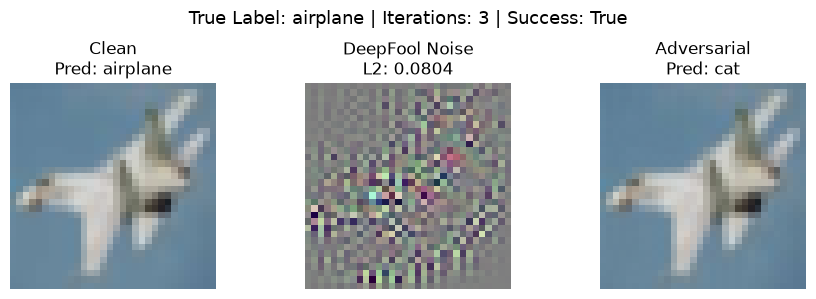

In [63]:
show_deepfool_example(
    model,
    test_loader,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=10
)

In [64]:
CW_STEPS = 100
CW_LR = 0.01
CW_C = 1.0
CW_KAPPA = 0.0
CW_EVAL_SIZE = 200

In [65]:
def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

In [66]:
def image_to_tanh_space(images, eps=1e-6):
    images = torch.clamp(images, eps, 1 - eps)
    return atanh(2 * images - 1)

In [67]:
def tanh_space_to_image(w):
    return 0.5 * (torch.tanh(w) + 1)

In [68]:
def cw_attack(
    model,
    images,
    labels,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()
    
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    
    batch_size = images.size(0)
    # optimize in the arctanh space
    w = image_to_tanh_space(images).detach()
    w.requires_grad = True
    
    optimizer = torch.optim.Adam([w], lr=lr)
    # use the best adversarial images found during optimization
    best_adv_images = images.clone().detach()
    best_l2 = torch.full((batch_size,), float("inf"), device=device)
    best_success = torch.zeros(batch_size, dtype=torch.bool, device=device)
    
    for step in range(num_steps):
        # convert w back to [0,1] for forward pass
        adv_images = tanh_space_to_image(w)
        
        logits = model(adv_images)
        # mask for the true labels
        one_hot_labels = F.one_hot(labels, num_classes=logits.size(1)).bool()
        # extract logits of the true class
        true_logits = logits.gather(1, labels.view(-1, 1)).squeeze(1)
        # highest logit among all wrong classes
        wrong_logits = logits.masked_fill(one_hot_labels, -float("inf"))
        max_wrong_logits = wrong_logits.max(dim=1).values
        # make sure the max wrong logit > true logit with a confidence kappa
        f_loss = torch.clamp(
            true_logits - max_wrong_logits,
            min=-kappa
        )
        # L2 distance
        l2_loss_per_sample = torch.sum(
            (adv_images - images) ** 2,
            dim=[1, 2, 3]
        )
        
        loss = l2_loss_per_sample + c * f_loss
        loss = loss.sum()
        # optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            success = preds != labels
            # should fool and also the loss should be small enough
            improved = success & (l2_loss_per_sample < best_l2)
            
            best_l2[improved] = l2_loss_per_sample[improved]
            best_adv_images[improved] = adv_images[improved].detach()
            best_success[improved] = True
            
    final_adv_images = best_adv_images.clone().detach()
        
    with torch.no_grad():
        final_logits = model(final_adv_images)
        final_preds = final_logits.argmax(dim=1)
        
    return final_adv_images, best_success, best_l2, final_preds

In [69]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images[:8].to(device)
sanity_check_labels = sanity_check_labels[:8].to(device)

sanity_check_adv_images, sanity_check_success, sanity_check_l2, sanity_check_preds = cw_attack(
    model=model,
    images=sanity_check_images,
    labels=sanity_check_labels,
    c=CW_C,
    kappa=CW_KAPPA,
    num_steps=CW_STEPS,
    lr=CW_LR,
    device=device
)

print("Success:", sanity_check_success.detach().cpu().numpy())
print("Preds:", sanity_check_preds.detach().cpu().numpy())
print("Labels:", sanity_check_labels.detach().cpu().numpy())
print("L2:", torch.sqrt(sanity_check_l2).detach().cpu().numpy())
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Success: [ True  True  True  True  True  True  True  True]
Preds: [5 1 1 8 4 3 9 2]
Labels: [3 8 8 0 6 6 1 6]
L2: [0.11152679 0.27922475 0.2155732  0.07049371 0.27661088 0.13614129
 0.17385152 0.11150578]
Adv min: 8.046627044677734e-07
Adv max: 0.9999991059303284


In [70]:
def evaluate_cw(
    model,
    loader,
    max_samples,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()
    
    total_samples = 0
    clean_correct = 0
    adv_correct = 0
    
    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []
    
    for images, labels in loader:
        remaining = max_samples - total_samples
        
        if remaining <= 0: 
            break
            
        images = images[:remaining].to(device, non_blocking=True)
        labels = labels[:remaining].to(device, non_blocking=True)
        
        with torch.no_grad():
            clean_logits = model(images)
            clean_preds = clean_logits.argmax(dim=1)
            
        initially_correct_mask = clean_preds == labels
        
        clean_correct += initially_correct_mask.sum().item()
        total_samples += labels.size(0)
        
        if initially_correct_mask.sum().item() == 0:
            continue
            
        images_to_attack = images[initially_correct_mask]
        labels_to_attack = labels[initially_correct_mask]
        
        adv_images, success, best_l2, final_preds = cw_attack(
            model,
            images_to_attack,
            labels_to_attack,
            c,
            kappa,
            num_steps,
            lr,
            device
        )
        
        attacked_samples += labels_to_attack.size(0)
        
        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_preds = adv_logits.argmax(dim=1)
            
        adv_correct += (adv_preds == labels_to_attack).sum().item()
        
        successful_mask = adv_preds != labels_to_attack
        successful_attacks += successful_mask.sum().item()
        
        if successful_mask.sum().item() > 0:
            successful_l2 = torch.sqrt(best_l2[successful_mask])
            l2_norm_successful.extend(successful_l2.detach().cpu().tolist())
            
        print(f"Processed {total_samples}/{max_samples} samples")
        
    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples
    
    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0
        
    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else:
        avg_l2_successful = 0.0
        
    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nC&W Results")
    print("-----------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after C&W: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results

In [71]:
cw_results = evaluate_cw(
    model,
    test_loader,
    CW_EVAL_SIZE,
    CW_C,
    CW_KAPPA,
    CW_STEPS,
    CW_LR,
    device
)

Processed 128/200 samples
Processed 200/200 samples

C&W Results
-----------
Total samples: 200
Clean accuracy: 0.9050
Robust accuracy after C&W: 0.0000
Attacked initially correct samples: 181
Successful attacks: 181
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.190604


In [72]:
def show_cw_example(
    model,
    loader,
    c,
    kappa,
    num_steps,
    lr,
    class_names,
    device,
    idx=0
):
    model.eval()

    clean_image, label = find_correct_sample(model, loader, device, idx)

    adv_image, success, best_l2, final_preds = cw_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        c=c,
        kappa=kappa,
        num_steps=num_steps,
        lr=lr,
        device=device
    )

    adv_image = adv_image.squeeze(0).detach().cpu()
    clean_image = clean_image.detach().cpu()

    perturbation = adv_image - clean_image
    l2_norm = torch.norm(perturbation.flatten(), p=2).item()

    clean_conf, clean_pred = get_confidence_and_pred(model, clean_image)
    adv_conf, adv_pred = get_confidence_and_pred(model, adv_image)

    max_abs_noise = perturbation.abs().max().item()

    if max_abs_noise > 0:
        noise_for_display = perturbation / (2 * max_abs_noise) + 0.5
    else:
        noise_for_display = perturbation + 0.5

    noise_for_display = torch.clamp(noise_for_display, 0.0, 1.0)

    images_to_show = [
        clean_image,
        noise_for_display,
        adv_image
    ]

    titles = [
        f"Clean\nPred: {class_names[clean_pred]}\nConf: {clean_conf:.2f}",
        f"C&W Noise\nL2: {l2_norm:.4f}",
        f"C&W Adv\nPred: {class_names[adv_pred]}\nConf: {adv_conf:.2f}"
    ]

    plt.figure(figsize=(9, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, 3, i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        f"True Label: {class_names[label.item()]} | "
        f"Success: {bool(success.item())}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

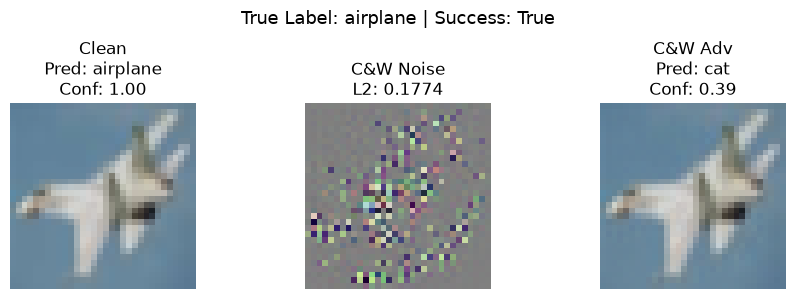

In [73]:
show_cw_example(
    model,
    test_loader,
    CW_C,
    CW_KAPPA,
    CW_STEPS,
    CW_LR,
    CIFAR10_CLASSES,
    device,
    idx=10
)

In [74]:
COMMON_SAMPLE_IDX = 20
COMMON_EPSILON = 8 / 255

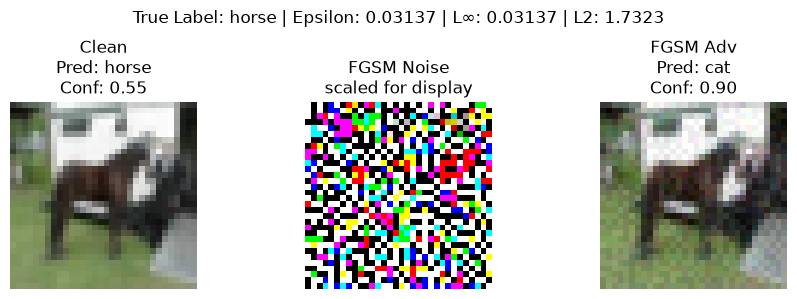

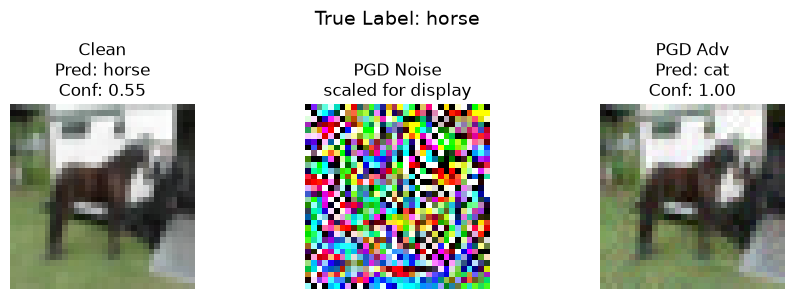

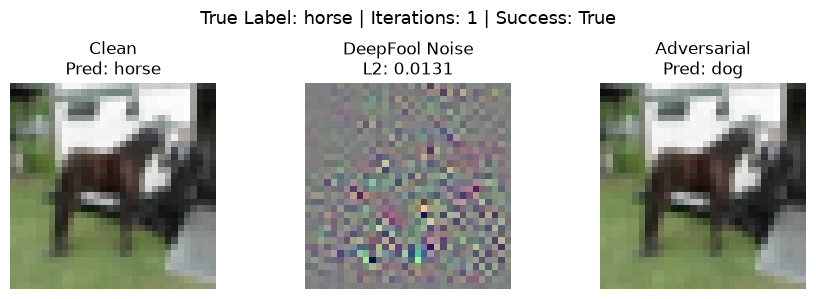

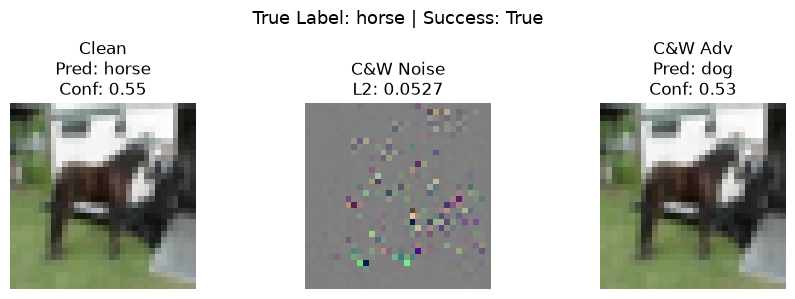

In [75]:
show_fgsm_example(
    model=model,
    loader=test_loader,
    epsilon=COMMON_EPSILON,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=COMMON_SAMPLE_IDX
)

show_pgd_example(
    model=model,
    loader=test_loader,
    epsilon=PGD_EPSILON,
    alpha=PGD_ALPHA,
    num_steps=PGD_STEPS,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    random_start=PGD_RANDOM_START,
    idx=COMMON_SAMPLE_IDX
)

show_deepfool_example(
    model=model,
    loader=test_loader,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=COMMON_SAMPLE_IDX
)

show_cw_example(
    model=model,
    loader=test_loader,
    c=CW_C,
    kappa=CW_KAPPA,
    num_steps=CW_STEPS,
    lr=CW_LR,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=COMMON_SAMPLE_IDX
)

In [76]:
ADV_TRAIN_EPOCHS = 15
ADV_TRAIN_LR = 0.1
ADV_TRAIN_MOMENTUM = 0.9
ADV_TRAIN_WEIGHT_DECAY = 5e-4

ADV_TRAIN_PGD_EPSILON = 8 / 255
ADV_TRAIN_PGD_ALPHA = 2 / 255
ADV_TRAIN_PGD_STEPS = 10
ADV_TRAIN_PGD_RANDOM_START = True

ADV_SAVE_PATH = "resnet20_cifar10_adversarial_training.pth"

In [77]:
adv_model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
adv_model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [78]:
adv_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
adv_model = adv_model.to(device)
print("Initialized adversarial training model from clean checkpoint.")

Initialized adversarial training model from clean checkpoint.


In [79]:
def adversarial_train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    epsilon,
    alpha,
    num_steps,
    random_start=True
):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        adv_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_steps,
            criterion,
            device,
            random_start
        )
        
        model.train()
        
        logits = model(adv_images)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [80]:
adv_saved_model_exists = False

In [81]:
if os.path.exists(ADV_SAVE_PATH):
    adv_model.load_state_dict(torch.load(ADV_SAVE_PATH, map_location=device))
    adv_model = adv_model.to(device)
    adv_model.eval()
    
    adv_saved_model_exists = True
    
    print(f"Loaded adversarially trained model from: {ADV_SAVE_PATH}")
else:
    print("No adversarially trained model found. Starting adversarial training.")

Loaded adversarially trained model from: resnet20_cifar10_adversarial_training.pth


In [82]:
if not adv_saved_model_exists:
    adv_criterion = nn.CrossEntropyLoss()
    
    adv_optimizer = torch.optim.SGD(
        adv_model.parameters(),
        lr=ADV_TRAIN_LR,
        momentum=ADV_TRAIN_MOMENTUM,
        weight_decay=ADV_TRAIN_WEIGHT_DECAY
    )
    
    adv_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        adv_optimizer,
        milestones=[6, 10],
        gamma=0.1
    )
    
    adv_history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    best_adv_val_acc = 0.0
    
    for epoch in range(ADV_TRAIN_EPOCHS):
        start_time = time.time()
        
        train_loss, train_acc = adversarial_train_one_epoch(
            adv_model,
            train_loader,
            adv_optimizer,
            adv_criterion,
            device,
            ADV_TRAIN_PGD_EPSILON,
            ADV_TRAIN_PGD_ALPHA,
            ADV_TRAIN_PGD_STEPS,
            ADV_TRAIN_PGD_RANDOM_START
        )
        
        val_loss, val_acc = evaluate(
            adv_model,
            val_loader,
            adv_criterion,
            device
        )
        
        adv_scheduler.step()
        
        adv_history["train_loss"].append(train_loss)
        adv_history["train_acc"].append(train_acc)
        adv_history["val_loss"].append(val_loss)
        adv_history["val_acc"].append(val_acc)
        
        if val_acc > best_adv_val_acc:
            best_adv_val_acc = val_acc
            torch.save(adv_model.state_dict(), ADV_SAVE_PATH)
            
        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{ADV_TRAIN_EPOCHS}] "
            f"adv_train_loss={train_loss:.4f} "
            f"adv_train_acc={train_acc:.4f} "
            f"clean_val_loss={val_loss:.4f} "
            f"clean_val_acc={val_acc:.4f} "
            f"lr={adv_scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )
    
    print("Best clean validation accuracy:", best_adv_val_acc)
    print("Saved adversarially trained model:", ADV_SAVE_PATH)
        
else:
    print("Skipping adversarial training because saved model already exists.")

Skipping adversarial training because saved model already exists.


In [83]:
if not adv_saved_model_exists:
    adv_model.load_state_dict(torch.load(ADV_SAVE_PATH, map_location=device))
    adv_model = adv_model.to(device)
    adv_model.eval()
    
    print("Loaded best adversarially trained model.")

In [84]:
if not adv_saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(adv_history["train_loss"], label="Adversarial Train Loss")
    plt.plot(adv_history["val_loss"], label="Clean Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Adversarial Training Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(adv_history["train_acc"], label="Adversarial Train Accuracy")
    plt.plot(adv_history["val_acc"], label="Clean Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Adversarial Training Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [85]:
COMPARE_FGSM_EPSILON = 8 / 255

COMPARE_PGD_EPSILON = 8 / 255
COMPARE_PGD_ALPHA = 2 / 255
COMPARE_PGD_STEPS = 20
COMPARE_PGD_RANDOM_START = True

COMPARE_DEEPFOOL_EVAL_SIZE = 500
COMPARE_CW_EVAL_SIZE = 200

In [86]:
def evaluate_model_against_attacks(
    model,
    model_name,
    test_loader,
    criterion,
    device
):
    print(f"\n==============================")
    print(f"Evaluating: {model_name}")
    print(f"==============================")

    results = {}

    # Clean
    clean_loss, clean_acc = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device
    )
    results["Clean"] = clean_acc

    print(f"Clean accuracy: {clean_acc:.4f}")

    # FGSM
    fgsm_result = evaluate_fgsm(
        model=model,
        loader=test_loader,
        epsilons=[COMPARE_FGSM_EPSILON],
        criterion=criterion,
        device=device
    )
    results["FGSM"] = fgsm_result[COMPARE_FGSM_EPSILON]

    # PGD
    pgd_acc = evaluate_pgd(
        model=model,
        loader=test_loader,
        epsilon=COMPARE_PGD_EPSILON,
        alpha=COMPARE_PGD_ALPHA,
        num_steps=COMPARE_PGD_STEPS,
        criterion=criterion,
        device=device,
        random_start=COMPARE_PGD_RANDOM_START
    )
    results["PGD"] = pgd_acc

    # DeepFool
    deepfool_result = evaluate_deepfool(
        model=model,
        loader=test_loader,
        max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
        num_classes=DEEPFOOL_NUM_CLASSES,
        max_iter=DEEPFOOL_MAX_ITER,
        overshoot=DEEPFOOL_OVERSHOOT,
        device=device
    )
    results["DeepFool"] = deepfool_result["robust_accuracy"]

    # C&W
    cw_result = evaluate_cw(
        model=model,
        loader=test_loader,
        max_samples=COMPARE_CW_EVAL_SIZE,
        c=CW_C,
        kappa=CW_KAPPA,
        num_steps=CW_STEPS,
        lr=CW_LR,
        device=device
    )
    results["C&W"] = cw_result["robust_accuracy"]

    return results

In [87]:
base_model_results = evaluate_model_against_attacks(
    model=model,
    model_name="Base Clean Model",
    test_loader=test_loader,
    criterion=criterion,
    device=device
)

adv_model_results = evaluate_model_against_attacks(
    model=adv_model,
    model_name="Adversarially Trained Model",
    test_loader=test_loader,
    criterion=criterion,
    device=device
)


Evaluating: Base Clean Model
Clean accuracy: 0.8927
epsilon=0.03137 | accuracy=0.0856
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=20: 0.0000
Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9080
Robust accuracy after DeepFool: 0.0000
Attacked initially correct samples: 454
Successful attacks: 454
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.108918
Processed 128/200 samples
Processed 200/200 samples

C&W Results
-----------
Total samples: 200
Clean accuracy: 0.9050
Robust accuracy after C&W: 0.0000
Attacked initially correct samples: 181
Successful attacks: 181
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.1906

In [88]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results
    }
).T

comparison_table_percent = comparison_table * 100
comparison_table_percent = comparison_table_percent.round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.27,8.56,0.00,0.0,0.0
Adversarial Training,68.16,43.39,39.73,0.4,35.0


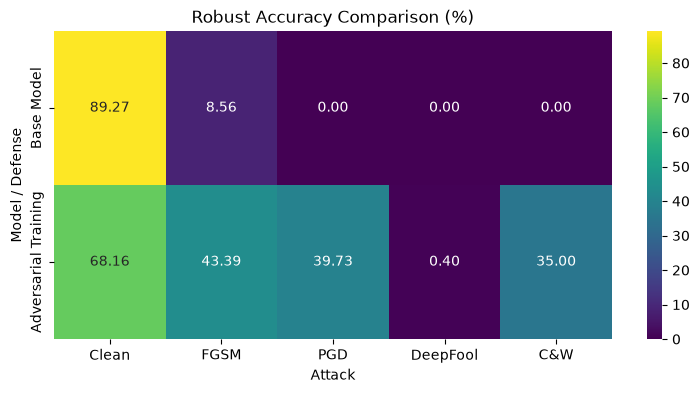

In [89]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()

In [90]:
base_deepfool_details = evaluate_deepfool(
    model=model,
    loader=test_loader,
    max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

adv_deepfool_details = evaluate_deepfool(
    model=adv_model,
    loader=test_loader,
    max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

deepfool_comparison = pd.DataFrame({
    "Base Model": base_deepfool_details,
    "Adversarial Training": adv_deepfool_details
}).T

deepfool_comparison[[
    "clean_accuracy",
    "robust_accuracy",
    "attacked_samples",
    "successful_attacks",
    "success_rate",
    "avg_l2_successful"
]]

Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9080
Robust accuracy after DeepFool: 0.0000
Attacked initially correct samples: 454
Successful attacks: 454
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.108917
Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.7000
Robust accuracy after DeepFool: 0.0000
Attacked initially correct samples: 350
Successful attacks: 350
Success rate on initiall

,clean_accuracy,robust_accuracy,attacked_samples,successful_attacks,success_rate,avg_l2_successful
Base Model,0.908,0.0,454.0,454.0,1.0,0.108917
Adversarial Training,0.700,0.0,350.0,350.0,1.0,1.210540


In [91]:
SMOOTH_EPOCHS = 20
SMOOTH_LR = 0.1
SMOOTH_MOMENTUM = 0.9
SMOOTH_WEIGHT_DECAY = 5e-4

SMOOTH_SIGMA = 0.25
SMOOTH_NUM_SAMPLES = 100

SMOOTH_SAVE_PATH = "resnet20_cifar10_randomized_smoothing.pth"

In [92]:
smooth_model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
smooth_model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [93]:
smooth_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
smooth_model = smooth_model.to(device)

print("Initialized randomized smoothing model from clean checkpoint.")

Initialized randomized smoothing model from clean checkpoint.


In [94]:
def add_gaussian_noise(images, sigma):
    noise = sigma * torch.randn_like(images)
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)
    
    return noisy_images

In [95]:
def gaussian_noise_train_one_sample(
    model,
    loader,
    optimizer,
    criterion,
    device,
    sigma
):
    model.train()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        noisy_images = add_gaussian_noise(images, sigma)
        
        logits = model(noisy_images)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [96]:
@torch.no_grad()
def evaluate_noisy(
    model,
    loader,
    criterion,
    device,
    sigma
):
    model.eval()
    
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        noisy_images = add_gaussian_noise(images, sigma)
        
        logits = model(noisy_images)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    
    return avg_loss, avg_acc

In [97]:
smooth_saved_model_exists = False

In [98]:
if os.path.exists(SMOOTH_SAVE_PATH):
    smooth_model.load_state_dict(torch.load(SMOOTH_SAVE_PATH, map_location=device))
    smooth_model = smooth_model.to(device)
    smooth_model.eval()
    
    smooth_saved_model_exists = True
    
    print(f"Loaded randomized smoothing model from: {SMOOTH_SAVE_PATH}")
else:
    print("No randomized smoothing model found. Starting Gaussian noise fine-tuning.")

Loaded randomized smoothing model from: resnet20_cifar10_randomized_smoothing.pth


In [99]:
if not smooth_saved_model_exists:
    smooth_criterion = nn.CrossEntropyLoss()
    
    smooth_optimizer = torch.optim.SGD(
        smooth_model.parameters(),
        lr=SMOOTH_LR,
        momentum=SMOOTH_MOMENTUM,
        weight_decay=SMOOTH_WEIGHT_DECAY
    )
    
    smooth_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        smooth_optimizer,
        milestones=[5, 15],
        gamma=0.1
    )
    
    smooth_history = {
        "train_loss": [],
        "train_acc": [],
        "clean_val_loss": [],
        "clean_val_acc": [],
        "noisy_val_loss": [],
        "noisy_val_acc": []
    }
    
    best_noisy_val_acc = 0.0
    
    for epoch in range(SMOOTH_EPOCHS):
        start_time = time.time()
        
        train_loss, train_acc = gaussian_noise_train_one_sample(
            smooth_model,
            train_loader,
            smooth_optimizer,
            smooth_criterion,
            device,
            SMOOTH_SIGMA
        )
        
        clean_val_loss, clean_val_acc = evaluate(
            smooth_model,
            val_loader,
            smooth_criterion,
            device
        )
        
        noisy_val_loss, noisy_val_acc = evaluate_noisy(
            smooth_model,
            val_loader,
            smooth_criterion,
            device,
            SMOOTH_SIGMA
        )
        
        smooth_scheduler.step()
        
        smooth_history["train_loss"].append(train_loss)
        smooth_history["train_acc"].append(train_acc)
        smooth_history["clean_val_loss"].append(clean_val_loss)
        smooth_history["clean_val_acc"].append(clean_val_acc)
        smooth_history["noisy_val_loss"].append(noisy_val_loss)
        smooth_history["noisy_val_acc"].append(noisy_val_acc)
        
        if noisy_val_acc > best_noisy_val_acc:
            best_noisy_val_acc = noisy_val_acc
            torch.save(smooth_model.state_dict(), SMOOTH_SAVE_PATH)
            
        elapsed = time.time() - start_time
        
        print(
            f"Epoch [{epoch + 1:02d}/{SMOOTH_EPOCHS}] "
            f"noisy_train_loss={train_loss:.4f} "
            f"noisy_train_acc={train_acc:.4f} "
            f"clean_val_acc={clean_val_acc:.4f} "
            f"noisy_val_acc={noisy_val_acc:.4f} "
            f"lr={smooth_scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )
        
    print("Best noisy validation accuracy:", best_noisy_val_acc)
    print("Saved randomized smoothing model:", SMOOTH_SAVE_PATH)
    
else:
    print("Skipping Gaussian noise fine-tuning because saved model already exists.")

Skipping Gaussian noise fine-tuning because saved model already exists.


In [100]:
if not smooth_saved_model_exists:
    smooth_model.load_state_dict(torch.load(SMOOTH_SAVE_PATH, map_location=device))
    smooth_model = smooth_model.to(device)
    smooth_model.eval()
    
    print("Loaded best randomized smoothing model.")

In [101]:
if not smooth_saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(smooth_history["train_loss"], label="Noisy Train Loss")
    plt.plot(smooth_history["clean_val_loss"], label="Clean Validation Loss")
    plt.plot(smooth_history["noisy_val_loss"], label="Noisy Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Gaussian Noise Fine-tuning Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(smooth_history["train_acc"], label="Noisy Train Accuracy")
    plt.plot(smooth_history["clean_val_acc"], label="Clean Validation Accuracy")
    plt.plot(smooth_history["noisy_val_acc"], label="Noisy Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Gaussian Noise Fine-tuning Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [102]:
smooth_criterion = nn.CrossEntropyLoss()

smooth_clean_test_loss, smooth_clean_test_acc = evaluate(
    model=smooth_model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device
)

base_noisy_test_loss, base_noisy_test_acc = evaluate_noisy(
    model=model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device,
    sigma=SMOOTH_SIGMA
)

smooth_noisy_test_loss, smooth_noisy_test_acc = evaluate_noisy(
    model=smooth_model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device,
    sigma=SMOOTH_SIGMA
)

print(f"Smooth model clean test accuracy: {smooth_clean_test_acc:.4f}")
print(f"Base   model noisy test accuracy: {base_noisy_test_acc:.4f}")
print(f"Smooth model noisy test accuracy: {smooth_noisy_test_acc:.4f}")

Smooth model clean test accuracy: 0.7221
Base   model noisy test accuracy: 0.1196
Smooth model noisy test accuracy: 0.7398


In [112]:
@torch.no_grad()
def randomized_smoothing_predict(
    model,
    images,
    device,
    sigma,
    num_samples,
    num_classes=10
):
    model.eval()
    
    images = images.to(device)
    batch_size = images.size(0)
    
    vote_counts = torch.zeros(
        batch_size,
        num_classes,
        device=device
    )
    
    for _ in range(num_samples):
        noisy_images = add_gaussian_noise(images, sigma)
        
        logits = model(noisy_images)
        preds = logits.argmax(dim=1)
        
        vote_counts.scatter_add_(
            dim=1,
            index=preds.view(-1, 1),
            src=torch.ones(batch_size, 1, device=device)
        )
        
    final_preds = vote_counts.argmax(dim=1)
    
    return final_preds, vote_counts

In [113]:
@torch.no_grad()
def evaluate_randomized_smoothing(
    model,
    loader,
    device,
    sigma,
    num_samples,
    max_samples=None,
    num_classes=10
):
    model.eval()
    
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        if max_samples is not None:
            remaining = max_samples - total_samples
            
            if remaining <= 0:
                break
                
            images = images[:remaining]
            labels = labels[:remaining]
        
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        preds, _ = randomized_smoothing_predict(
            model=model,
            images=images,
            device=device,
            sigma=sigma,
            num_samples=num_samples,
            num_classes=num_classes
        )
        
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        print(f"Processed {total_samples} samples")
        
        if max_samples is not None and total_samples >= max_samples:
            break
    
    accuracy = total_correct / total_samples
    
    print(
        f"Randomized smoothing accuracy | "
        f"sigma={sigma}, "
        f"N={num_samples}, "
        f"samples={total_samples}: "
        f"{accuracy:.4f}"
    )
    
    return accuracy

In [120]:
SMOOTH_EVAL_SIZE = 1000

In [121]:
smooth_clean_acc = evaluate_randomized_smoothing(
    smooth_model,
    test_loader,
    device,
    SMOOTH_SIGMA,
    SMOOTH_NUM_SAMPLES,
    SMOOTH_EVAL_SIZE,
    10
)

print(f"Smoothed clean accuracy: {smooth_clean_acc:.4f}")

Processed 128 samples
Processed 256 samples
Processed 384 samples
Processed 512 samples
Processed 640 samples
Processed 768 samples
Processed 896 samples
Processed 1000 samples
Randomized smoothing accuracy | sigma=0.25, N=100, samples=1000: 0.7970
Smoothed clean accuracy: 0.7970


In [127]:
def evaluate_attack_with_smoothing(
    model,
    loader,
    attack_name,
    criterion,
    device,
    sigma,
    num_smoothing_samples,
    max_samples=None,
    num_classes=10
):
    model.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        if max_samples is not None:
            remaining = max_samples - total_samples

            if remaining <= 0:
                break

            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if attack_name == "FGSM":
            adv_images = fgsm_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=COMPARE_FGSM_EPSILON,
                criterion=criterion,
                device=device
            )

        elif attack_name == "PGD":
            adv_images = pgd_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=COMPARE_PGD_EPSILON,
                alpha=COMPARE_PGD_ALPHA,
                num_steps=COMPARE_PGD_STEPS,
                criterion=criterion,
                device=device,
                random_start=COMPARE_PGD_RANDOM_START
            )

        elif attack_name == "DeepFool":
            adv_images_list = []

            for i in range(images.size(0)):
                image = images[i]
                label = labels[i]

                with torch.no_grad():
                    clean_logits = model(image.unsqueeze(0))
                    clean_pred = clean_logits.argmax(dim=1).item()

                if clean_pred != label.item():
                    adv_images_list.append(image.detach().cpu())
                    continue

                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    model=model,
                    image=image,
                    device=device,
                    num_classes=DEEPFOOL_NUM_CLASSES,
                    max_iter=DEEPFOOL_MAX_ITER,
                    overshoot=DEEPFOOL_OVERSHOOT
                )

                adv_images_list.append(adv_image.detach().cpu())

            adv_images = torch.stack(adv_images_list).to(device)

        elif attack_name == "C&W":
            with torch.no_grad():
                clean_logits = model(images)
                clean_preds = clean_logits.argmax(dim=1)

            initially_correct_mask = clean_preds == labels

            adv_images = images.clone().detach()

            if initially_correct_mask.sum().item() > 0:
                images_to_attack = images[initially_correct_mask]
                labels_to_attack = labels[initially_correct_mask]

                cw_adv_images, success, best_l2, final_preds = cw_attack(
                    model=model,
                    images=images_to_attack,
                    labels=labels_to_attack,
                    c=CW_C,
                    kappa=CW_KAPPA,
                    num_steps=CW_STEPS,
                    lr=CW_LR,
                    device=device
                )

                adv_images[initially_correct_mask] = cw_adv_images.detach()

        else:
            raise ValueError(f"Unknown attack name: {attack_name}")

        preds, vote_counts = randomized_smoothing_predict(
            model=model,
            images=adv_images,
            device=device,
            sigma=sigma,
            num_samples=num_smoothing_samples,
            num_classes=num_classes
        )

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"{attack_name} + smoothing | Processed {total_samples} samples")

        if max_samples is not None and total_samples >= max_samples:
            break

    accuracy = total_correct / total_samples

    print(f"{attack_name} + smoothing accuracy: {accuracy:.4f}")

    return accuracy

In [128]:
def evaluate_smooth_model_against_attacks(
    model,
    model_name,
    test_loader,
    criterion,
    device,
    sigma,
    num_smoothing_samples,
    max_samples=None,
    num_classes=10
):
    print(f"\n==============================")
    print(f"Evaluating smoothed model: {model_name}")
    print(f"Sigma: {sigma}, N: {num_smoothing_samples}")
    print(f"==============================")

    results = {}

    # ---------------- Clean + Smoothing ----------------
    clean_acc = evaluate_randomized_smoothing(
        model=model,
        loader=test_loader,
        device=device,
        sigma=sigma,
        num_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["Clean"] = clean_acc

    # ---------------- FGSM + Smoothing ----------------
    fgsm_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="FGSM",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["FGSM"] = fgsm_acc

    # ---------------- PGD + Smoothing ----------------
    pgd_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="PGD",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["PGD"] = pgd_acc

    # ---------------- DeepFool + Smoothing ----------------
    deepfool_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="DeepFool",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["DeepFool"] = deepfool_acc

    # ---------------- C&W + Smoothing ----------------
    cw_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="C&W",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["C&W"] = cw_acc

    return results

In [129]:
SMOOTH_COMPARE_EVAL_SIZE = 500

In [130]:
smooth_model_results = evaluate_smooth_model_against_attacks(
    smooth_model,
    "Randomized Smoothing",
    test_loader,
    criterion,
    device,
    SMOOTH_SIGMA,
    SMOOTH_NUM_SAMPLES,
    SMOOTH_COMPARE_EVAL_SIZE,
    10
)

smooth_model_results


Evaluating smoothed model: Randomized Smoothing
Sigma: 0.25, N: 100
Processed 128 samples
Processed 256 samples
Processed 384 samples
Processed 500 samples
Randomized smoothing accuracy | sigma=0.25, N=100, samples=500: 0.8040
FGSM + smoothing | Processed 128 samples
FGSM + smoothing | Processed 256 samples
FGSM + smoothing | Processed 384 samples
FGSM + smoothing | Processed 500 samples
FGSM + smoothing accuracy: 0.3600
PGD + smoothing | Processed 128 samples
PGD + smoothing | Processed 256 samples
PGD + smoothing | Processed 384 samples
PGD + smoothing | Processed 500 samples
PGD + smoothing accuracy: 0.3320
DeepFool + smoothing | Processed 128 samples
DeepFool + smoothing | Processed 256 samples
DeepFool + smoothing | Processed 384 samples
DeepFool + smoothing | Processed 500 samples
DeepFool + smoothing accuracy: 0.6960
C&W + smoothing | Processed 128 samples
C&W + smoothing | Processed 256 samples
C&W + smoothing | Processed 384 samples
C&W + smoothing | Processed 500 samples
C&W

{'Clean': 0.804, 'FGSM': 0.36, 'PGD': 0.332, 'DeepFool': 0.696, 'C&W': 0.714}

In [131]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results,
        "Randomized Smoothing": smooth_model_results
    }
).T

comparison_table_percent = (comparison_table * 100).round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.27,8.56,0.00,0.0,0.0
Adversarial Training,68.16,43.39,39.73,0.4,35.0
Randomized Smoothing,80.40,36.00,33.20,69.6,71.4


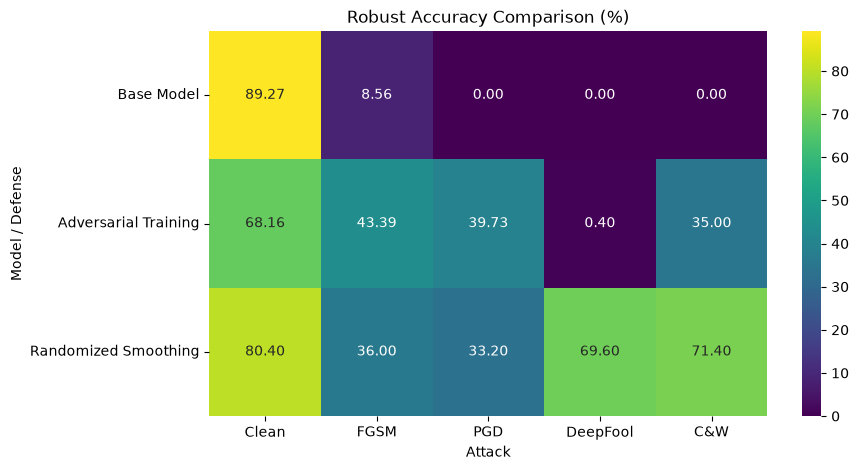

In [132]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()

In [133]:
!pip install diffusers accelerate -q

In [135]:
from diffusers import DDPMPipeline

In [136]:
DIFFPURE_MODEL_NAME = "google/ddpm-cifar10-32"

DIFFPURE_T = 50
DIFFPURE_EVAL_SIZE = 200
DIFFPURE_BATCH_SIZE = 16

DIFFPURE_CLIP_MIN = 0.0
DIFFPURE_CLIP_MAX = 1.0

In [137]:
ddpm_pipeline = DDPMPipeline.from_pretrained(DIFFPURE_MODEL_NAME)
ddpm_pipeline = ddpm_pipeline.to(device)

ddpm_unet = ddpm_pipeline.unet
ddpm_scheduler = ddpm_pipeline.scheduler

ddpm_unet.eval()

print("Loaded DDPM model:", DIFFPURE_MODEL_NAME)

Loading pipeline components...:   0%|                                                               | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch /home/ali/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /home/ali/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|███████████████████████████████████████████████████████| 2/2 [00:00<00:00, 34.42it/s]

Loaded DDPM model: google/ddpm-cifar10-32


In [138]:
def image_0_1_to_minus1_1(images):
    return images * 2.0 - 1.0

def image_minus1_1_to_0_1(images):
    return (images + 1.0) / 2.0

In [139]:
@torch.no_grad()
def diffpure_purify_images(
    images,
    unet,
    scheduler,
    device,
    t=50
):
    unet.eval()
    
    images = images.clone().detach().to(device)
    
    x0 = image_0_1_to_minus1_1(images)
    
    batch_size = images.size(0)
    
    timesteps = torch.full(
        (batch_size,), 
        t,
        device=device,
        dtype=torch.long
    )
    
    noise = torch.randn_like(x0)
    
    xt = scheduler.add_noise(
        original_samples=x0,
        noise=noise,
        timesteps=timesteps
    )
    
    sample = xt 
    
    for current_t in range(t, -1, -1):
        timestep_tensor = torch.full(
            (batch_size,), 
            current_t,
            device=device,
            dtype=torch.long
        )
        
        noise_pred = unet(
            sample,
            timestep_tensor
        ).sample
        
        step_output = scheduler.step(
            model_output=noise_pred,
            timestep=current_t,
            sample=sample
        )
        
        sample = step_output.prev_sample
        
    purified_images = image_minus1_1_to_0_1(sample)
    purified_images = torch.clamp(purified_images, 0.0, 1.0)
    
    return purified_images.detach()

In [140]:
sample_images, sample_labels = next(iter(test_loader))

sample_images = sample_images[:8].to(device)

purified_images = diffpure_purify_images(
    images=sample_images,
    unet=ddpm_unet,
    scheduler=ddpm_scheduler,
    device=device,
    t=DIFFPURE_T
)

print("Original min/max:", sample_images.min().item(), sample_images.max().item())
print("Purified min/max:", purified_images.min().item(), purified_images.max().item())
print("Purified shape:", purified_images.shape)

assert purified_images.min().item() >= 0.0
assert purified_images.max().item() <= 1.0

Original min/max: 0.0 1.0
Purified min/max: 0.0 1.0
Purified shape: torch.Size([8, 3, 32, 32])


In [141]:
def show_diffpure_clean_examples(
    images,
    purified_images,
    num_images=8
):
    images = images.detach().cpu()
    purified_images = purified_images.detach().cpu()
    
    plt.figure(figsize=(2 * num_images, 4))
    
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        img_np = images[i].permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0.0, 1.0)
        plt.imshow(img_np)
        plt.title("Original")
        plt.axis("off")
        
        # Purified
        plt.subplot(2, num_images, num_images + i + 1)
        pur_np = purified_images[i].permute(1, 2, 0).detach().cpu().numpy()
        pur_np = np.clip(pur_np, 0.0, 1.0)
        plt.imshow(pur_np)
        plt.title("Purified")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

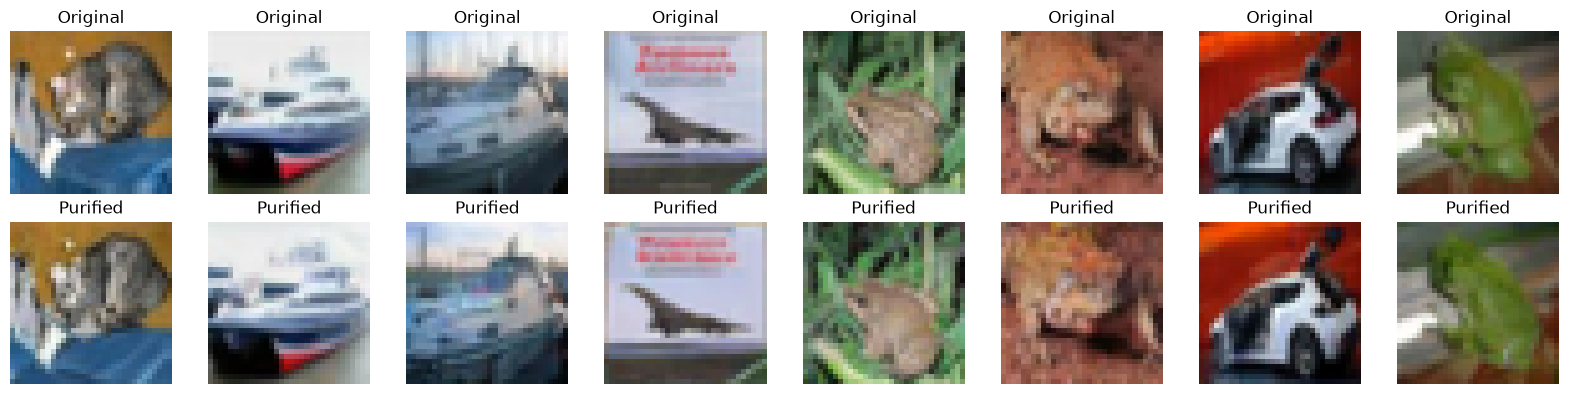

In [142]:
show_diffpure_clean_examples(
    images=sample_images,
    purified_images=purified_images,
    num_images=8
)

In [145]:
def evaluate_diffpure_clean(
    classifier, 
    loader,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    classifier.eval()
    unet.eval()
    
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        remaining = max_samples - total_samples
        
        if remaining <= 0:
            break
            
        images = images[:remaining]
        labels = labels[:remaining]
        
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        purified_images = diffpure_purify_images(
            images,
            unet,
            scheduler,
            device,
            t
        )
        
        with torch.no_grad():
            logits = classifier(purified_images)
            preds = logits.argmax(dim=1)
            
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        print(f"DiffPure clean | Processed {total_samples}/{max_samples} samples")
    
    accuracy = total_correct / total_samples
    
    print(f"DiffPure clean accuracy: {accuracy:.4f}")
    
    return accuracy

In [146]:
diffpure_clean_acc = evaluate_diffpure_clean(
    model,
    test_loader,
    ddpm_unet,
    ddpm_scheduler,
    device,
    DIFFPURE_T,
    DIFFPURE_EVAL_SIZE
)

DiffPure clean | Processed 128/200 samples
DiffPure clean | Processed 200/200 samples
DiffPure clean accuracy: 0.8800


In [150]:
def evaluate_attack_with_diffpure(
    classifier,
    loader,
    attack_name,
    criterion,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    classifier.eval()
    unet.eval()
    
    total_correct = 0
    total_samples = 0
    
    for images, labels in loader:
        remaining = max_samples - total_samples
        
        if remaining <= 0:
            break
            
        images = images[:remaining]
        labels = labels[:remaining]
        
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        if attack_name == "FGSM":
            adv_images = fgsm_attack(
                classifier,
                images,
                labels,
                COMPARE_FGSM_EPSILON,
                criterion,
                device
            )
            
        elif attack_name == "PGD":
            adv_images = pgd_attack(
                classifier,
                images,
                labels,
                COMPARE_PGD_EPSILON,
                COMPARE_PGD_ALPHA,
                COMPARE_PGD_STEPS,
                criterion,
                device,
                COMPARE_PGD_RANDOM_START
            )
            
        elif attack_name == "DeepFool":
            adv_images_list = []
            
            for i in range(images.size(0)):
                image = images[i]
                label = labels[i]
                
                with torch.no_grad():
                    clean_logits = classifier(image.unsqueeze(0))
                    clean_pred = clean_logits.argmax(dim=1).item()
                    
                if clean_pred != label.item():
                    adv_images_list.append(image.detach().cpu())
                    continue
                    
                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    classifier,
                    image,
                    device,
                    DEEPFOOL_NUM_CLASSES,
                    DEEPFOOL_MAX_ITER,
                    DEEPFOOL_OVERSHOOT
                )
                
                adv_images_list.append(adv_image.detach().cpu())
                
            adv_images = torch.stack(adv_images_list).to(device)
            
        elif attack_name == "C&W":
            with torch.no_grad():
                clean_logits = classifier(images)
                clean_preds = clean_logits.argmax(dim=1)
                
            initially_correct_mask = clean_preds == labels
            
            adv_images = images.clone().detach()
            
            if initially_correct_mask.sum().item() > 0:
                images_to_attack = images[initially_correct_mask]
                labels_to_attack = labels[initially_correct_mask]
                
                cw_adv_images, success, best_l2, final_preds = cw_attack(
                    classifier,
                    images_to_attack,
                    labels_to_attack,
                    CW_C,
                    CW_KAPPA,
                    CW_STEPS,
                    CW_LR,
                    device
                )
                
                adv_images[initially_correct_mask] = cw_adv_images.detach()
                
        else:
            raise ValueError(f"Unknown attack name: {attack_name}")

        purified_images = diffpure_purify_images(
            adv_images,
            unet,
            scheduler,
            device,
            t
        )

        with torch.no_grad():
            logits = classifier(purified_images)
            preds = logits.argmax(dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"{attack_name} + DiffPure | Processed {total_samples}/{max_samples} samples")
            
    accuracy = total_correct / total_samples
        
    print(f"{attack_name} + DiffPure accuracy: {accuracy:.4f}")
        
    return accuracy

In [151]:
def evaluate_diffpure_against_attacks(
    classifier,
    model_name,
    test_loader,
    criterion,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    print(f"\n==============================")
    print(f"Evaluating DiffPure: {model_name}")
    print(f"t = {t}")
    print(f"==============================")
    
    results = {}
    
    # Clean
    clean_acc = evaluate_diffpure_clean(
        classifier=classifier,
        loader=test_loader,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    results["Clean"] = clean_acc
    
    # FGSM
    results["FGSM"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="FGSM",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    
    # PGD
    results["PGD"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="PGD",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    
    # DeepFool
    results["DeepFool"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="DeepFool",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    
    # C&W
    results["C&W"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="C&W",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    
    return results

In [152]:
diffpure_results = evaluate_diffpure_against_attacks(
    model,
    "Diffusion Purification",
    test_loader,
    criterion,
    ddpm_unet,
    ddpm_scheduler,
    device,
    DIFFPURE_T,
    DIFFPURE_EVAL_SIZE
)

diffpure_results


Evaluating DiffPure: Diffusion Purification
t = 50
DiffPure clean | Processed 128/200 samples
DiffPure clean | Processed 200/200 samples
DiffPure clean accuracy: 0.8900
FGSM + DiffPure | Processed 128/200 samples
FGSM + DiffPure | Processed 200/200 samples
FGSM + DiffPure accuracy: 0.6500
PGD + DiffPure | Processed 128/200 samples
PGD + DiffPure | Processed 200/200 samples
PGD + DiffPure accuracy: 0.6900
DeepFool + DiffPure | Processed 128/200 samples
DeepFool + DiffPure | Processed 200/200 samples
DeepFool + DiffPure accuracy: 0.8650
C&W + DiffPure | Processed 128/200 samples
C&W + DiffPure | Processed 200/200 samples
C&W + DiffPure accuracy: 0.8650


{'Clean': 0.89, 'FGSM': 0.65, 'PGD': 0.69, 'DeepFool': 0.865, 'C&W': 0.865}

In [153]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results,
        "Randomized Smoothing": smooth_model_results,
        "Diffusion Purification": diffpure_results
    }
).T

comparison_table_percent = (comparison_table * 100).round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.27,8.56,0.00,0.0,0.0
Adversarial Training,68.16,43.39,39.73,0.4,35.0
Randomized Smoothing,80.40,36.00,33.20,69.6,71.4
Diffusion Purification,89.00,65.00,69.00,86.5,86.5


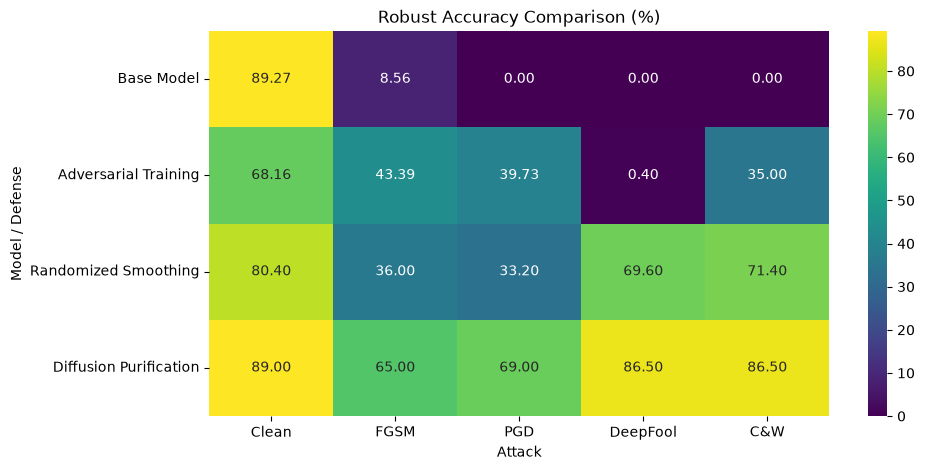

In [154]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()